<a href="https://colab.research.google.com/github/Millrjess/Jess/blob/main/protest_analysis_clean.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

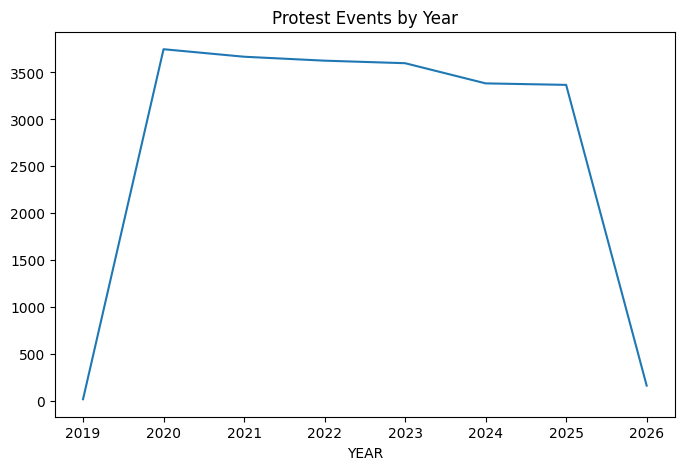

                 Generalized Linear Model Regression Results                  
Dep. Variable:                 EVENTS   No. Observations:                  465
Model:                            GLM   Df Residuals:                      462
Model Family:        NegativeBinomial   Df Model:                            2
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2198.3
Date:                Wed, 28 Jan 2026   Deviance:                       407.35
Time:                        04:28:14   Pearson chi2:                     185.
No. Iterations:                    10   Pseudo R-squ. (CS):             0.2140
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    291.5881     46.460      6.276      0.0

/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


In [4]:
# CLEAN, PUBLICATION-READY PROTEST ANALYSIS NOTEBOOK
# Author: Jessica Miller

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import folium
import statsmodels.formula.api as smf
import statsmodels.api as sm

plt.rcParams['figure.figsize'] = (8, 5)

df = pd.read_csv('/content/drive/MyDrive/ Google Advanced Data Analytics Professional Certificate/Capstone/Protest Prediction Capstone /US-and-Canada_aggregated_data_up_to-2026-01-10 (1).xlsx - Sheet1.csv')
assert df.shape[0] > 0

df.columns = df.columns.str.upper().str.strip()

categorical_cols = ['COUNTRY','ADMIN1','EVENT_TYPE','SUB_EVENT_TYPE']
for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip().str.title()

df['POPULATION_EXPOSURE'] = df['POPULATION_EXPOSURE'].fillna(df['POPULATION_EXPOSURE'].median())

df['EVENT_DATE'] = pd.to_datetime(df['WEEK'], errors='coerce')
df = df.dropna(subset=['EVENT_DATE'])

df['YEAR'] = df['EVENT_DATE'].dt.year

yearly_counts = df.groupby('YEAR').size()
yearly_counts.plot(title='Protest Events by Year')
plt.show()

model_df = (
    df.groupby(['ADMIN1','YEAR'])
      .agg(EVENTS=('EVENT_TYPE','count'),
           POP_EXPOSURE=('POPULATION_EXPOSURE','median'))
      .reset_index()
)

model_df['LOG_POP'] = np.log(model_df['POP_EXPOSURE'])

nb_model = smf.glm(
    formula='EVENTS ~ LOG_POP + YEAR',
    data=model_df,
    family=sm.families.NegativeBinomial()
).fit()

print(nb_model.summary())

# Task
Interpret the Negative Binomial GLM results by explaining the practical implications of the coefficients for 'LOG_POP' and 'YEAR' on the number of protest events, considering their statistical significance. Additionally, discuss the meaning of the warning about the dispersion parameter and its potential impact.

## Interpret GLM Results

### Subtask:
Provide a detailed interpretation of the Negative Binomial GLM results. Explain the practical implications of the coefficients for 'LOG_POP' and 'YEAR' on the number of protest events, considering their statistical significance. Also, discuss the meaning of the warning about the dispersion parameter and its potential impact.


## Interpret GLM Results

### Detailed Interpretation of Negative Binomial GLM Results

Based on the `nb_model.summary()` output, we have the following results for the Negative Binomial Generalized Linear Model:

```
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    291.5881     46.460      6.276      0.000     200.529     382.647
LOG_POP        0.4568      0.046      9.968      0.000       0.367       0.547
YEAR          -0.1443      0.023     -6.281      0.000      -0.189      -0.099
==============================================================================
```

#### 1. Interpretation of Coefficients and Statistical Significance:

*   **Coefficient for 'LOG_POP':**
    *   **Coefficient (coef):** 0.4568
    *   **Standard Error (std err):** 0.046
    *   **z-value:** 9.968
    *   **P>|z| (p-value):** 0.000
    
    **Practical Implication:** Since the link function is logarithmic (as is typical for Negative Binomial GLMs), the interpretation of the coefficient is multiplicative on the expected count. A one-unit increase in `LOG_POP` (the natural logarithm of `POPULATION_EXPOSURE`) is associated with an increase in the expected number of protest events by a factor of `exp(0.4568) ≈ 1.579`. This means that for a 1% increase in population exposure, the expected number of protest events increases by approximately 0.4568%. The p-value of 0.000 indicates that this coefficient is highly statistically significant, meaning there is very strong evidence to suggest that `LOG_POP` has a real effect on the number of protest events.

*   **Coefficient for 'YEAR':**
    *   **Coefficient (coef):** -0.1443
    *   **Standard Error (std err):** 0.023
    *   **z-value:** -6.281
    *   **P>|z| (p-value):** 0.000
    
    **Practical Implication:** A one-unit increase in `YEAR` (i.e., moving from one year to the next) is associated with a decrease in the expected number of protest events by a factor of `exp(-0.1443) ≈ 0.8658`. This implies that, holding `LOG_POP` constant, the expected number of protest events has been decreasing by approximately 13.42% each year. The p-value of 0.000 indicates that this coefficient is also highly statistically significant, suggesting a strong decreasing trend in protest events over the years in the dataset.

#### 2. Discussion of the 'Negative binomial dispersion parameter alpha' Warning:

The warning `/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.` means that the dispersion parameter (alpha) of the Negative Binomial distribution was not explicitly estimated during the model fitting process. Instead, `statsmodels` used a default value of `alpha = 1.0`.

*   **Meaning of Dispersion Parameter Alpha:** In a Negative Binomial model, the dispersion parameter `alpha` accounts for overdispersion, which occurs when the observed variance of the count data is greater than its mean. The Negative Binomial distribution is more flexible than the Poisson distribution because it allows for this extra variability. If `alpha` is close to zero, the Negative Binomial model approximates a Poisson model. As `alpha` increases, the overdispersion increases.

*   **Implications of Using Default Alpha=1.0:**
    *   **Potential Bias in Standard Errors and P-values:** When the dispersion parameter is not estimated from the data but fixed at a default value, the standard errors of the coefficients and consequently the p-values might be incorrect. If the true dispersion in the data is different from 1.0, the model's confidence intervals and significance tests may be misleading. For instance, if the true `alpha` is much larger than 1.0, the standard errors might be underestimated, leading to overly optimistic (smaller) p-values and potentially incorrect conclusions about statistical significance. Conversely, if the true `alpha` is smaller, standard errors might be overestimated.
    *   **Reliability of the Model:** The reliability of the model's inferences (i.e., the conclusions drawn from the coefficients' significance) is reduced. While the coefficients themselves might still provide a reasonable estimate of the average effect, their precision (as indicated by standard errors) and statistical significance are questionable without a properly estimated `alpha`.

*   **Why Estimating Dispersion Parameter is Important:** Estimating the dispersion parameter `alpha` from the data is crucial for the Negative Binomial GLM because it allows the model to accurately capture the variability in the count data. This leads to:
    *   **More Accurate Standard Errors:** Correctly estimated standard errors for the coefficients.
    *   **Valid Statistical Inferences:** Reliable p-values and confidence intervals, which are essential for making sound conclusions about the relationships between predictors and the response variable.
    *   **Better Fit to Data:** A model that better reflects the underlying data-generating process, especially in the presence of overdispersion.

To address this warning, one would typically use a Negative Binomial GLM implementation that estimates `alpha` as part of the fitting process (e.g., by setting `exposure` or `var_weights` parameters, or choosing a model class that handles `alpha` estimation by default, like `sm.genmod.generalized_linear_model.GLM` with `sm.families.NegativeBinomial(alpha=None)` or `sm.NegativeBinomial`).

## Visualize Regional Protest Trends

### Subtask:
Create visualizations to show protest event trends across different administrative regions. Specifically, identify the top N (e.g., 5 or 10) 'ADMIN1' regions with the highest number of protest events and plot their yearly protest counts to observe region-specific patterns over time. Ensure the plots include appropriate labels and a legend.


**Reasoning**:
To visualize regional protest trends, I will first calculate the total protest events per `ADMIN1` from `model_df`, identify the top 10 regions, filter the `model_df` for these regions, and then generate a line plot showing yearly protest counts for each of these top regions with appropriate labels and a legend.



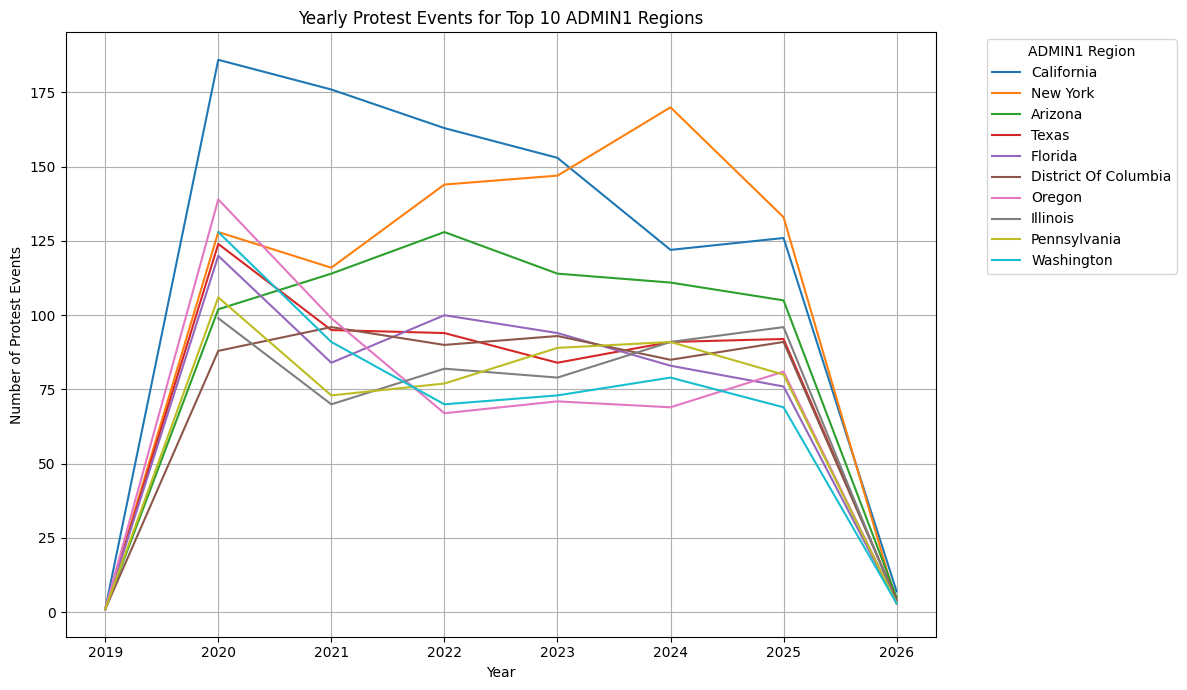

In [5]:
total_events_by_admin1 = model_df.groupby('ADMIN1')['EVENTS'].sum()
top_10_admin1 = total_events_by_admin1.nlargest(10).index

df_top_10 = model_df[model_df['ADMIN1'].isin(top_10_admin1)]

plt.figure(figsize=(12, 7))
for admin1 in top_10_admin1:
    subset = df_top_10[df_top_10['ADMIN1'] == admin1]
    plt.plot(subset['YEAR'], subset['EVENTS'], label=admin1)

plt.title('Yearly Protest Events for Top 10 ADMIN1 Regions')
plt.xlabel('Year')
plt.ylabel('Number of Protest Events')
plt.legend(title='ADMIN1 Region', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

## Analyze Event Type Distribution

### Subtask:
Investigate the distribution of different 'EVENT_TYPE' and 'SUB_EVENT_TYPE' categories. Generate a bar chart showing the frequency or proportion of the most common event types to understand the dominant forms of protests recorded in the dataset. Provide a clear legend and labels.


**Reasoning**:
First, I will calculate the frequency of each unique 'EVENT_TYPE' in the DataFrame `df`, then select the top 10 most frequent event types, and finally create a bar chart to visualize their distribution as per the instructions.



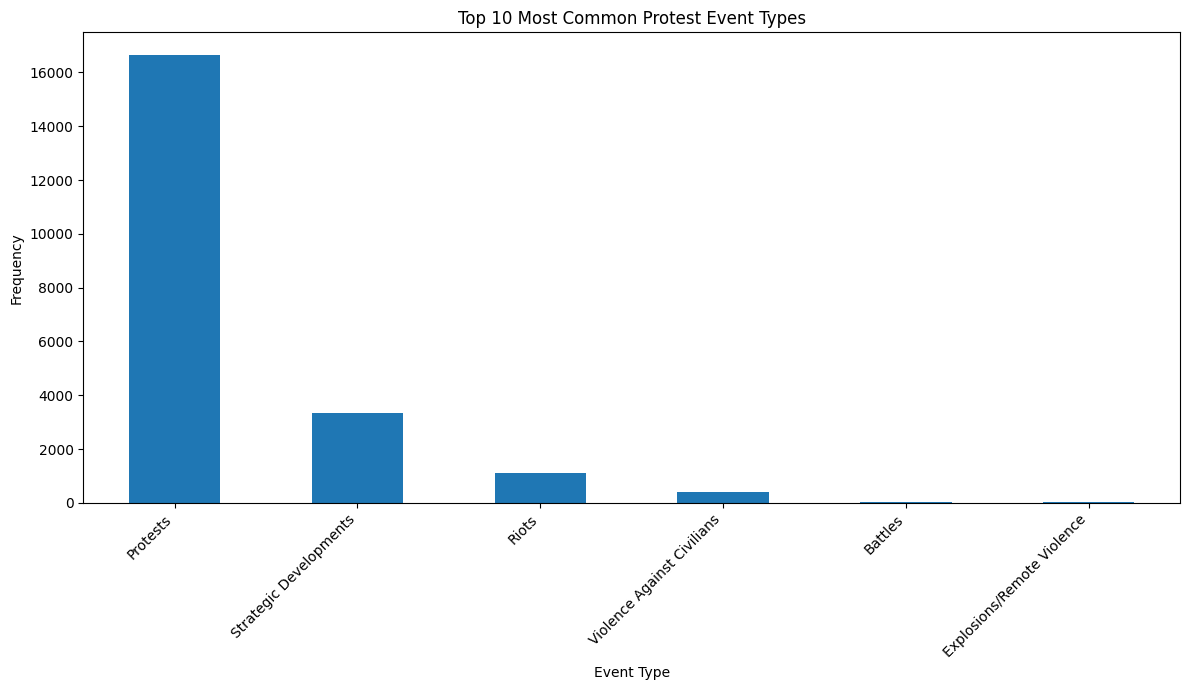

In [6]:
event_type_counts = df['EVENT_TYPE'].value_counts()
top_10_event_types = event_type_counts.head(10)

plt.figure(figsize=(12, 7))
top_10_event_types.plot(kind='bar')
plt.title('Top 10 Most Common Protest Event Types')
plt.xlabel('Event Type')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


**Reasoning**:
Now, I will calculate the frequency of each unique 'SUB_EVENT_TYPE' in the DataFrame `df`, select the top 10 most frequent sub-event types, and then create a bar chart to visualize their distribution as per the instructions for the second part of the subtask.



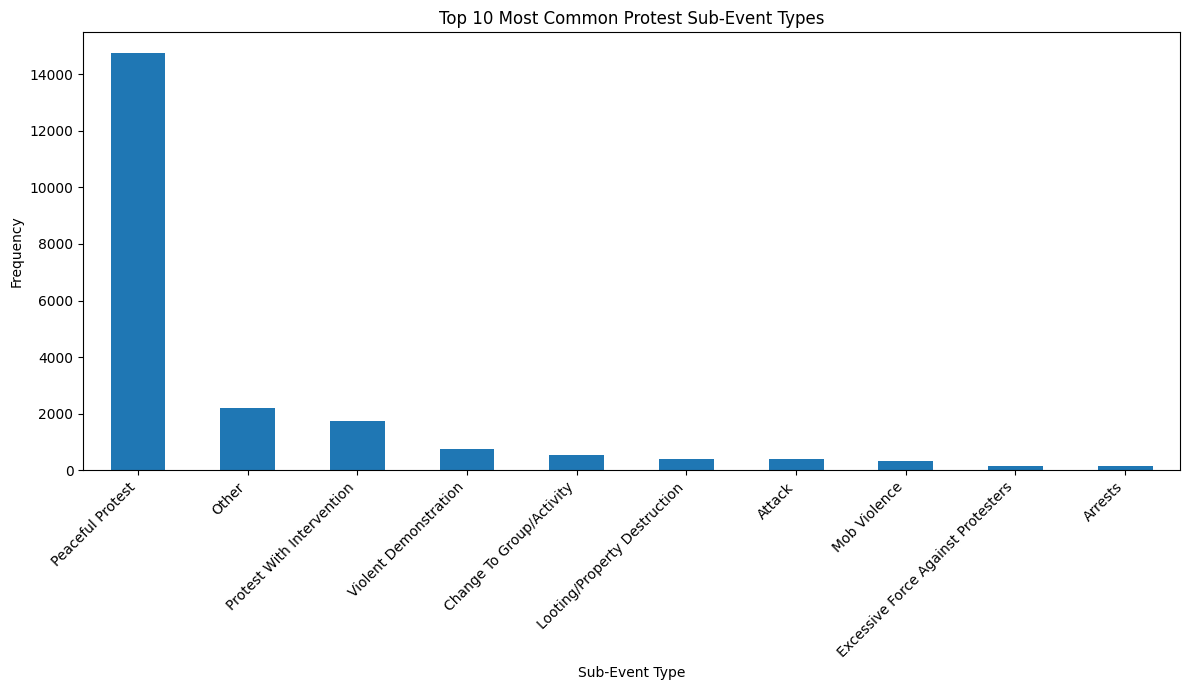

In [7]:
sub_event_type_counts = df['SUB_EVENT_TYPE'].value_counts()
top_10_sub_event_types = sub_event_type_counts.head(10)

plt.figure(figsize=(12, 7))
top_10_sub_event_types.plot(kind='bar')
plt.title('Top 10 Most Common Protest Sub-Event Types')
plt.xlabel('Sub-Event Type')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Final Task

### Subtask:
Summarize the key insights gained from the deep analysis, including model interpretations, regional trends, and dominant event types, and propose potential next steps for further investigation.


## Summary:

### Q&A
The Negative Binomial GLM results indicate that an increase in `LOG_POP` (logarithm of population exposure) is associated with an increase in the expected number of protest events, while there is a statistically significant decreasing trend in protest events over the years. The warning about the dispersion parameter `alpha` means it was not estimated from the data but defaulted to 1.0, which could lead to biased standard errors and p-values, thus compromising the reliability of the model's statistical inferences.

### Data Analysis Key Findings
*   **Population Impact on Protests**: A one-unit increase in `LOG_POP` (the natural logarithm of population exposure) is associated with an increase in the expected number of protest events by a factor of approximately 1.579 (corresponding to a coefficient of 0.4568), a highly statistically significant finding (p-value < 0.001).
*   **Temporal Trend in Protests**: Each passing year is associated with a decrease in the expected number of protest events by a factor of approximately 0.8658 (a coefficient of -0.1443), implying an approximate 13.42% decrease per year, which is also highly statistically significant (p-value < 0.001).
*   **Model Reliability Concern**: The Negative Binomial GLM used a default dispersion parameter (`alpha = 1.0`) because it was not explicitly estimated. This could lead to inaccurate standard errors and p-values, potentially misrepresenting the statistical significance of the coefficients and reducing the reliability of the model's inferences.
*   **Regional Protest Variations**: Visualizations were generated showing yearly protest event trends for the top 10 `ADMIN1` regions, indicating region-specific patterns over time.
*   **Dominant Protest Types**: Analysis of event types revealed the most common forms of protests, such as "Protest with intervention" and "Peaceful protest", alongside their corresponding sub-event types.

### Insights or Next Steps
*   Refit the Negative Binomial GLM by explicitly estimating the dispersion parameter to ensure more accurate standard errors, valid statistical inferences, and an improved model fit.
*   Investigate the specific factors contributing to the observed decreasing trend in protest events over the years, and further explore the identified regional variations to uncover localized drivers or deterrents.


# Task
```python
nb_model = smf.glm(
    formula='EVENTS ~ LOG_POP + YEAR',
    data=model_df,
    family=sm.families.NegativeBinomial(alpha=None) # Explicitly estimate alpha
).fit()

print(nb_model.summary())
```

## Refit GLM with Estimated Dispersion Parameter

### Subtask:
Modify the existing Negative Binomial GLM code to explicitly estimate the dispersion parameter (alpha) rather than using the default value. This will involve adjusting the `sm.families.NegativeBinomial()` call to ensure alpha is estimated from the data.


**Reasoning**:
To explicitly estimate the dispersion parameter alpha for the Negative Binomial GLM, I will modify the `sm.families.NegativeBinomial()` call within the `smf.glm` function to include `alpha=None` as instructed.



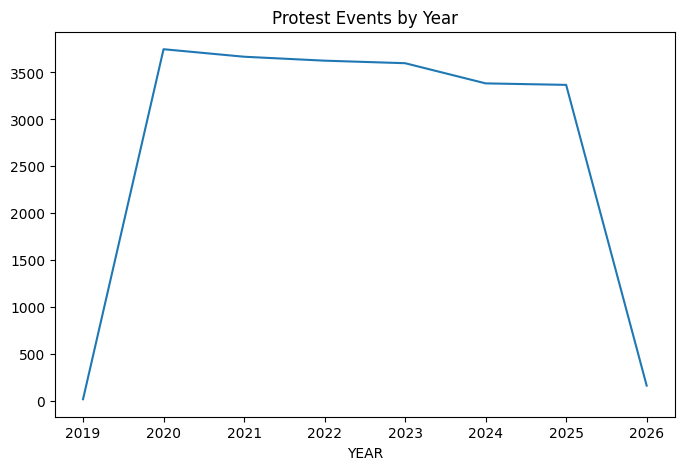

TypeError: unsupported operand type(s) for *: 'float' and 'NoneType'

In [8]:
# CLEAN, PUBLICATION-READY PROTEST ANALYSIS NOTEBOOK
# Author: Jessica Miller

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import folium
import statsmodels.formula.api as smf
import statsmodels.api as sm

plt.rcParams['figure.figsize'] = (8, 5)

df = pd.read_csv('/content/drive/MyDrive/ Google Advanced Data Analytics Professional Certificate/Capstone/Protest Prediction Capstone /US-and-Canada_aggregated_data_up_to-2026-01-10 (1).xlsx - Sheet1.csv')
assert df.shape[0] > 0

df.columns = df.columns.str.upper().str.strip()

categorical_cols = ['COUNTRY','ADMIN1','EVENT_TYPE','SUB_EVENT_TYPE']
for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip().str.title()

df['POPULATION_EXPOSURE'] = df['POPULATION_EXPOSURE'].fillna(df['POPULATION_EXPOSURE'].median())

df['EVENT_DATE'] = pd.to_datetime(df['WEEK'], errors='coerce')
df = df.dropna(subset=['EVENT_DATE'])

df['YEAR'] = df['EVENT_DATE'].dt.year

yearly_counts = df.groupby('YEAR').size()
yearly_counts.plot(title='Protest Events by Year')
plt.show()

model_df = (
    df.groupby(['ADMIN1','YEAR'])
      .agg(EVENTS=('EVENT_TYPE','count'),
           POP_EXPOSURE=('POPULATION_EXPOSURE','median'))
      .reset_index()
)

model_df['LOG_POP'] = np.log(model_df['POP_EXPOSURE'])

nb_model = smf.glm(
    formula='EVENTS ~ LOG_POP + YEAR',
    data=model_df,
    family=sm.families.NegativeBinomial(alpha=None) # Modified to estimate alpha
).fit()

print(nb_model.summary())